In [1]:
import os
import glob
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt

In [8]:
# ==============================================================================
# 1. CONFIGURACIÓN DE RUTA Y PARÁMETROS BENCHMARK
# ==============================================================================
# Cambia esta ruta por la carpeta donde guardes los archivos CSV de la sesión
CARPETA_RESULTADOS = "C:/Users/david/Downloads/results_"  # Ejemplo: "C:/usuarios/tu_nombre/datos_taller"

In [9]:
# ==============================================================================
# BENCHMARK NORMATIVO ADOLESCENTE (BATERÍA COMPLETA: NEUTRAS, FELICES Y TRISTES)
# Batería de Tottenham et al. (2009)
#Tottenham, N., Tanaka, J. W., Leon, A. C., McCarry, T., Nurse, M., Hare, T. A., Marcus, D. J., Westerlund, A., Casey, B. J., & Nelson, C. (2009). The NimStim set of facial expressions: Judgments from untrained research participants. Psychiatry Research, 168(3), 242–249. https://doi.org/10.1016/j.psychres.2008.05.006

# ==============================================================================
# Fuente: Manelis et al. (2024). Behav Sci, 14(9), 826. (PMC11429131)
# Datos extraídos del Material Suplementario (Figura S2 - Muestra 13-17 años, N = 35)
#
# Razón del cálculo:
# Los datos brutos simples de la escala 1-9 no muestran diferencias de edad en 
# la puntuación media (los adolescentes y adultos promedian valores similares). 
# Sin embargo, al transformar la respuesta a distancia absoluta (I = |x - 5|):
#   - Caras Tristes  (x = 2.18) -> I = |2.18 - 5| = 2.82
#   - Caras Felices  (x = 7.95) -> I = |7.95 - 5| = 2.95
#   - Caras Neutras  (x = 4.66) -> I = |4.66 - 5| = 0.34
#
# Promedio global de intensidad I = (2.82 + 2.95 + 0.34) / 3 = 2.04
# Desviación Estándar derivada de SE=0.06 (SD = 0.06 * sqrt(35) ≈ 0.35)
# ==============================================================================

BENCHMARK_JONES_MEAN = 2.04
BENCHMARK_JONES_SD = 0.35
BENCHMARK_JONES_N = 35
BENCHMARK_JONES_CI = (1.92, 2.16)

In [10]:
# # ==============================================================================
# # 2. PROCESAMIENTO DE ARCHIVOS CSV
# # ==============================================================================

# def cargar_datos_taller(carpeta):
#     archivos_csv = glob.glob(os.path.join(carpeta, "*.csv"))
#     if not archivos_csv:
#         raise FileNotFoundError(f"No se encontraron archivos CSV en la ruta: {carpeta}")
    
#     sujetos_medias = []
#     sujetos_ids = []
    
#     for archivo in archivos_csv:
#         try:
#             df = pd.read_csv(archivo)
#             if 'key_resp_2.keys' in df.columns:
#                 keys = pd.to_numeric(df['key_resp_2.keys'], errors='coerce').dropna()
#                 if len(keys) > 0:
#                     # Cálculo de desviación absoluta respecto al punto neutro (5)
#                     intensidades = (keys - 5).abs()
#                     sujetos_medias.append(intensidades.mean())
                    
#                     # ID del participante
#                     p_id = df['participant'].iloc[0] if 'participant' in df.columns and not pd.isna(df['participant'].iloc[0]) else os.path.basename(archivo)
#                     sujetos_ids.append(str(p_id))
#         except Exception as e:
#             print(f"Error al leer {archivo}: {e}")
            
#     return np.array(sujetos_medias), sujetos_ids

In [20]:
def cargar_datos_taller(carpeta):
    archivos_csv = glob.glob(os.path.join(carpeta, "*.csv"))
    if not archivos_csv:
        raise FileNotFoundError(f"No se encontraron archivos CSV en la ruta: {carpeta}")
    
    sujetos_medias = []
    sujetos_ids = []
    lista_dfs = []
    
    for archivo in archivos_csv:
        try:
            df_ind = pd.read_csv(archivo)
            if 'key_resp_2.keys' in df_ind.columns:
                # Convertir a numérico y descartar 'None' o nulos
                df_ind['key_resp_2.keys'] = pd.to_numeric(df_ind['key_resp_2.keys'], errors='coerce')
                df_valid = df_ind.dropna(subset=['key_resp_2.keys']).copy()
                
                if len(df_valid) > 0:
                    # Crear la columna de Intensidad ensayo a ensayo
                    df_valid['I'] = (df_valid['key_resp_2.keys'] - 5).abs()
                    
                    # Guardar la media del sujeto
                    sujetos_medias.append(df_valid['I'].mean())
                    
                    # ID del participante
                    p_id = df_ind['participant'].iloc[0] if 'participant' in df_ind.columns and not pd.isna(df_ind['participant'].iloc[0]) else os.path.basename(archivo)
                    sujetos_ids.append(str(p_id))
                    
                    # Guardar el DataFrame del participante
                    lista_dfs.append(df_valid)
        except Exception as e:
            print(f"Error al leer {archivo}: {e}")
            
    df_taller = pd.concat(lista_dfs, ignore_index=True) if lista_dfs else pd.DataFrame()
    return np.array(sujetos_medias), sujetos_ids, df_taller

In [21]:
# ==============================================================================
# 3. CÁLCULO DE BOOTSTRAP IC 95%
# ==============================================================================
def calcular_bootstrap_ci(data, n_boot=10000, ci=95):
    if len(data) == 1:
        return data[0], data[0]
    boot_means = [np.mean(np.random.choice(data, size=len(data), replace=True)) for _ in range(n_boot)]
    low = np.percentile(boot_means, (100 - ci) / 2)
    high = np.percentile(boot_means, 100 - (100 - ci) / 2)
    return low, high



def obtener_estrellas(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return 'n.s.'

In [24]:
# ==============================================================================
# 4. EJECUCIÓN Y VISUALIZACIÓN
# ==============================================================================
scores, ids, df_taller = cargar_datos_taller(CARPETA_RESULTADOS)
n_sujetos = len(scores)

media_adultos = np.mean(scores)
ci_low, ci_high = calcular_bootstrap_ci(scores)

print(f"\n--- RESUMEN DE MUESTRA ---")
print(f"Número de participantes analizados: {n_sujetos}")
for pid, sc in zip(ids, scores):
    print(f"  • Sujeto '{pid}': {sc:.3f}")

print(f"\nMedia Adultos (Taller): {media_adultos:.3f} | IC 95% Bootstrap: [{ci_low:.3f}, {ci_high:.3f}]")
print(f"Media Jóvenes (Benchmark): {BENCHMARK_JONES_MEAN:.3f} | IC 95%: [{BENCHMARK_JONES_CI[0]:.3f}, {BENCHMARK_JONES_CI[1]:.3f}]")


--- RESUMEN DE MUESTRA ---
Número de participantes analizados: 2
  • Sujeto 'dani_OB_01_09_2026': 1.762
  • Sujeto 'Dani_test2': 1.833

Media Adultos (Taller): 1.798 | IC 95% Bootstrap: [1.762, 1.833]
Media Jóvenes (Benchmark): 2.040 | IC 95%: [1.920, 2.160]


In [25]:
# ==============================================================================
# TEST ESTADÍSTICO DE DOS MUESTRAS (Welch's t-Test con Benchmark de Literatura)
# ==============================================================================
# 1. Estadísticos de la muestra del taller (Adultos)
media_adultos = np.mean(scores)
sd_adultos = np.std(scores, ddof=1) if n_sujetos > 1 else np.std(intensidades, ddof=1)
n_adultos = n_sujetos if n_sujetos > 1 else len(intensidades)

# 2. Test de Welch para varianzas no iguales incorporando la variabilidad de ambos grupos
t_stat, p_val = stats.ttest_ind_from_stats(
    mean1=media_adultos, std1=sd_adultos, nobs1=n_adultos,
    mean2=BENCHMARK_JONES_MEAN, std2=BENCHMARK_JONES_SD, nobs2=BENCHMARK_JONES_N,
    equal_var=False
)

# Cohen's d ponderado
pooled_sd = np.sqrt(((n_adultos - 1) * sd_adultos**2 + (BENCHMARK_JONES_N - 1) * BENCHMARK_JONES_SD**2) / (n_adultos + BENCHMARK_JONES_N - 2))
cohen_d = (media_adultos - BENCHMARK_JONES_MEAN) / pooled_sd

print(f"\n=== TEST DE WELCH (Incorporando variabilidad del Benchmark) ===")
print(f"Estadístico t: {t_stat:.4f}")
print(f"p-valor: {p_val:.4e}")



#### Interpretar p-valor
if p_val < 0.05:
    print("-> CONCLUSIÓN: Existe una diferencia ESTADÍSTICAMENTE SIGNIFICATIVA (p < 0.05) con la referencia de jóvenes.")
else:
    print("-> CONCLUSIÓN: No se observa una diferencia estadísticamente significativa (p >= 0.05).")

estrellas = obtener_estrellas(p_val)


print("")


#### Interpretar d' cohen
def interpretar_cohen_d(d):
    abs_d = abs(d)
    
    # 1. Grado de Solapamiento en Porcentaje (OVL)
    # Mide el porcentaje de área compartida entre las dos distribuciones normales
    porcentaje_solapamiento = 2 * stats.norm.cdf(-abs_d / 2) * 100
    
    # 2. Dirección del efecto
    direccion = "inferior" if d < 0 else "superior"
    
    # 3. Clasificación de la magnitud (|d|)
    if abs_d < 0.2:
        magnitud = "Despreciable"
        explicacion = "La diferencia entre ambos grupos es irrelevante en la práctica."
    elif abs_d < 0.5:
        magnitud = "Pequeño"
        explicacion = "Diferencia sutil pero detectable. Hay mucho solapamiento entre grupos."
    elif abs_d < 0.8:
        magnitud = "Moderado"
        explicacion = "Diferencia sustancial y perceptible a simple vista en la práctica."
    elif abs_d < 1.2:
        magnitud = "Grande"
        explicacion = "Diferencia muy clara. Los dos grupos están bien diferenciados."
    else:  # abs_d >= 1.2
        magnitud = "Muy grande"
        explicacion = "Diferencia masiva. Los dos grupos se comportan de forma casi disjunta."

    # 4. Impresión de resultados
    print(f"=== INTERPRETACIONAL DE COHEN'S d = {d:.4f} ===")
    print(f"• Magnitud del efecto: {magnitud}")
    print(f"• Dirección: El grupo evaluado es {direccion} al grupo de referencia.")
    print(f"• Porcentaje de solapamiento (OVL): {porcentaje_solapamiento:.1f}%")
    print(f"• Interpretación: {explicacion}")



interpretar_cohen_d(cohen_d)


=== TEST DE WELCH (Incorporando variabilidad del Benchmark) ===
Estadístico t: -3.5074
p-valor: 4.6105e-03
-> CONCLUSIÓN: Existe una diferencia ESTADÍSTICAMENTE SIGNIFICATIVA (p < 0.05) con la referencia de jóvenes.

=== INTERPRETACIONAL DE COHEN'S d = -0.7024 ===
• Magnitud del efecto: Moderado
• Dirección: El grupo evaluado es inferior al grupo de referencia.
• Porcentaje de solapamiento (OVL): 72.5%
• Interpretación: Diferencia sustancial y perceptible a simple vista en la práctica.


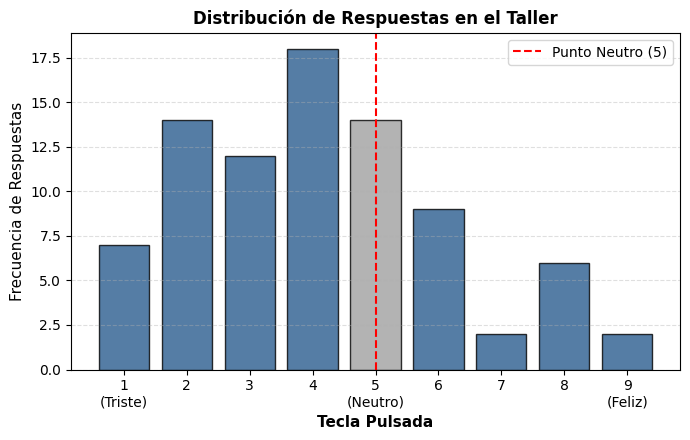

In [27]:
# ------------------------------------------------------------------------------
# Gráfico 1: Distribución de Respuestas Brutas (1 al 9)
# ------------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 4.5))

# Conteo de teclas del 1 al 9
conteo_teclas = df_taller['key_resp_2.keys'].value_counts().reindex(range(1, 10), fill_value=0)

# Colores: neutro en gris, extremos emocionales en azul
colores = ['#2b5c8f' if k != 5 else '#a0a0a0' for k in range(1, 10)]

bars = ax.bar(conteo_teclas.index, conteo_teclas.values, color=colores, edgecolor='black', alpha=0.8)

# Resaltar la barra del 5 (punto neutro)
ax.axvline(5, color='red', linestyle='--', linewidth=1.5, label='Punto Neutro (5)')

ax.set_xticks(range(1, 10))
ax.set_xticklabels(['1\n(Triste)', '2', '3', '4', '5\n(Neutro)', '6', '7', '8', '9\n(Feliz)'])
ax.set_xlabel('Tecla Pulsada', fontsize=11, fontweight='bold')
ax.set_ylabel('Frecuencia de Respuestas', fontsize=11)
ax.set_title('Distribución de Respuestas en el Taller', fontsize=12, fontweight='bold')
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.legend()

plt.tight_layout()
#plt.savefig('distribucion_respuestas_taller.png', dpi=300, transparent=True)
plt.show()

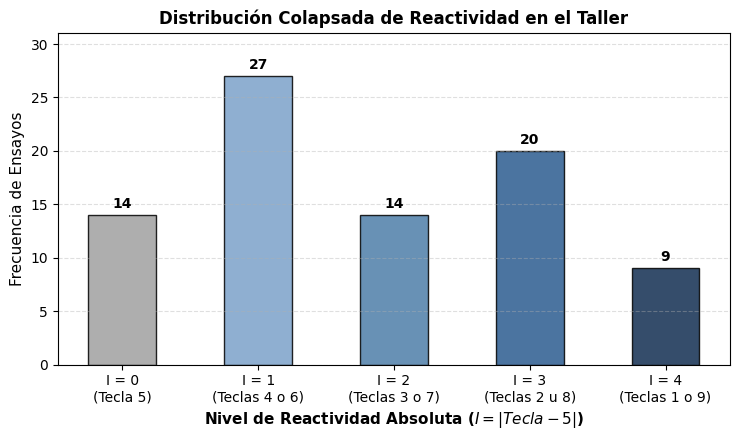

In [32]:
# ------------------------------------------------------------------------------
# Gráfico 1B: Distribución de Reactividad Colapsada en Absoluto (I = |Tecla - 5|)
# ------------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7.5, 4.5))

# Aseguramos el cálculo de la intensidad absoluta I por ensayo
df_taller['I'] = (df_taller['key_resp_2.keys'] - 5).abs()

# Conteo de frecuencias colapsadas para los valores 0, 1, 2, 3 y 4
conteo_I = df_taller['I'].value_counts().reindex(range(0, 5), fill_value=0)

# Gradiente cromático: de gris neutro (I=0) a azul intenso/reactivo (I=4)
colores_I = ['#a0a0a0', '#7ca1c9', '#4d7ea8', '#2b5c8f', '#112e51']

bars = ax.bar(conteo_I.index, conteo_I.values, color=colores_I, edgecolor='black', alpha=0.85, width=0.5)

# Añadir el número total de ensayos sobre cada columna
for bar in bars:
    height = bar.get_height()
    if height > 0:
        ax.text(bar.get_x() + bar.get_width()/2, height + (max(conteo_I.values) * 0.015),
                f'{int(height)}', ha='center', va='bottom', fontweight='bold', fontsize=10)

# Etiquetas de las x que explican exactamente qué teclas se colapsaron
ax.set_xticks(range(0, 5))
ax.set_xticklabels([
    'I = 0\n(Tecla 5)',
    'I = 1\n(Teclas 4 o 6)',
    'I = 2\n(Teclas 3 o 7)',
    'I = 3\n(Teclas 2 u 8)',
    'I = 4\n(Teclas 1 o 9)'
], fontsize=10)

ax.set_xlabel('Nivel de Reactividad Absoluta ($I = |Tecla - 5|$)', fontsize=11, fontweight='bold')
ax.set_ylabel('Frecuencia de Ensayos', fontsize=11)
ax.set_title('Distribución Colapsada de Reactividad en el Taller', fontsize=12, fontweight='bold')
ax.grid(axis='y', linestyle='--', alpha=0.4)

# Ajuste del límite vertical para que los números sobre las barras no se corten
ax.set_ylim(0, max(conteo_I.values) * 1.15)

plt.tight_layout()
# plt.savefig(os.path.join(CARPETA_RESULTADOS, 'distribucion_colapsada_taller.png'), dpi=300, transparent=True)
plt.show()

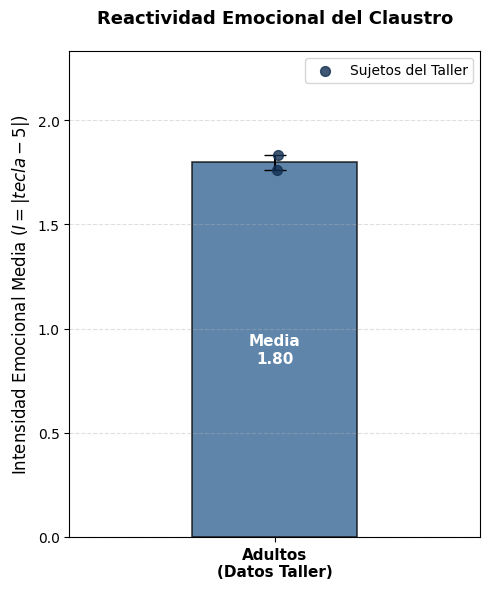

¡Gráfico de columna única guardado en: C:/Users/david/Downloads/results_\reactividad_emocional_taller_unicolumna.png!


In [18]:
# ------------------------------------------------------------------------------
# Generación del Gráfico (Únicamente Datos del Taller)
# ------------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(5, 6))

x = [0]
means = [media_adultos]
yerr = [[media_adultos - ci_low], [ci_high - media_adultos]]

# Barra única de adultos
bar = ax.bar(x, means, yerr=yerr, capsize=8, color='#2b5c8f', alpha=0.75, width=0.4, edgecolor='black', linewidth=1.2)

# Etiqueta de valor dentro de la barra
ax.text(bar[0].get_x() + bar[0].get_width()/2, media_adultos/2, f"Media\n{media_adultos:.2f}", 
        ha='center', va='center', color='white', fontweight='bold', fontsize=11)

# Puntos individuales de los adultos con jitter horizontal
if n_sujetos > 0:
    jitter = np.random.normal(0, 0.02, size=n_sujetos) if n_sujetos > 1 else [0]
    ax.scatter(jitter, scores, color='#112e51', s=50, alpha=0.8, zorder=3, label='Sujetos del Taller')

# Ajustes de formato visual
ax.set_xticks(x)
ax.set_xticklabels(['Adultos\n(Datos Taller)'], fontsize=11, fontweight='bold')
ax.set_ylabel('Intensidad Emocional Media ($I = |tecla - 5|$)', fontsize=12)
ax.set_title('Reactividad Emocional del Claustro', fontsize=13, fontweight='bold', pad=20)

# Límite superior adaptativo basado en el máximo entre el IC y las puntuaciones individuales
y_max = max(ci_high, max(scores) if len(scores) > 0 else ci_high) + 0.5
ax.set_ylim(0, y_max)
ax.set_xlim(-0.5, 0.5)

ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.legend(loc='upper right', frameon=True)

plt.tight_layout()

nombre_archivo_taller = os.path.join(CARPETA_RESULTADOS, 'reactividad_emocional_taller_unicolumna.png')
#plt.savefig(nombre_archivo_taller, dpi=300, transparent=True, bbox_inches='tight')
plt.show()



¡Gráfico de datos del taller guardado: C:/Users/david/Downloads/results_\datos_taller_tres_columnas.png!


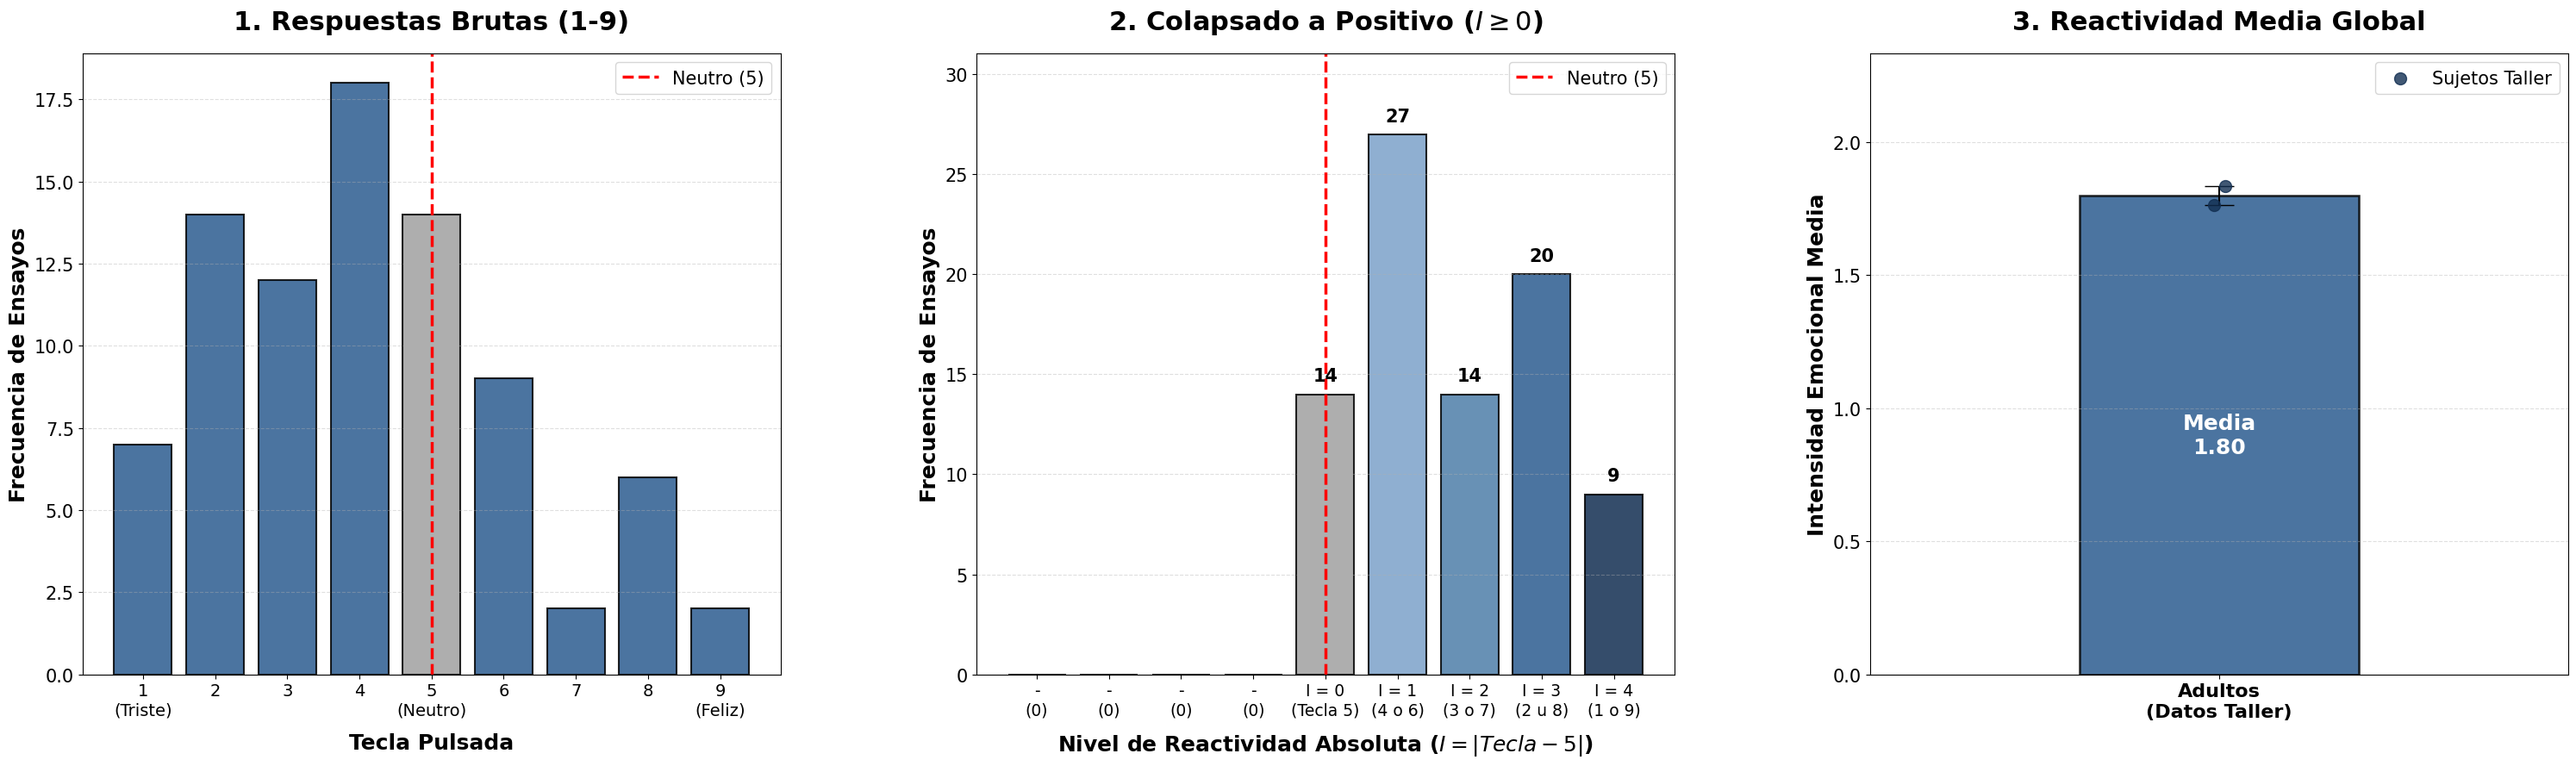

In [51]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------------------------
# Figura de 3 Subplots (Formato Gigante 30x9 con Fuentes Maximizadas)
# ------------------------------------------------------------------------------
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(30, 9))

# ==============================================================================
# SUBPLOT 1: Frecuencias Brutas (Teclas 1 a 9)
# ==============================================================================
conteo_teclas = df_taller['key_resp_2.keys'].value_counts().reindex(range(1, 10), fill_value=0)
colores_raw = ['#2b5c8f' if k != 5 else '#a0a0a0' for k in range(1, 10)]

bars1 = ax1.bar(conteo_teclas.index, conteo_teclas.values, color=colores_raw, edgecolor='black', linewidth=1.5, alpha=0.85)
ax1.axvline(5, color='red', linestyle='--', linewidth=2.5, label='Neutro (5)')

ax1.set_xticks(range(1, 10))
ax1.set_xticklabels(['1\n(Triste)', '2', '3', '4', '5\n(Neutro)', '6', '7', '8', '9\n(Feliz)'], fontsize=14)
ax1.set_xlabel('Tecla Pulsada', fontsize=18, fontweight='bold', labelpad=12)
ax1.set_ylabel('Frecuencia de Ensayos', fontsize=18, fontweight='bold')
ax1.set_title('1. Respuestas Brutas (1-9)', fontsize=22, fontweight='bold', pad=20)
ax1.tick_params(axis='y', labelsize=15)
ax1.grid(axis='y', linestyle='--', alpha=0.4)
ax1.legend(loc='upper right', fontsize=15)


# ==============================================================================
# SUBPLOT 2: Frecuencia Colapsada en Positivo en Eje Completo (1 a 9)
# ==============================================================================
df_taller['I'] = (df_taller['key_resp_2.keys'] - 5).abs()
conteo_I = df_taller['I'].value_counts().reindex(range(0, 5), fill_value=0)

frecuencias_positivas = [0, 0, 0, 0, conteo_I[0], conteo_I[1], conteo_I[2], conteo_I[3], conteo_I[4]]

paleta_eje = ['none', 'none', 'none', 'none', '#a0a0a0', '#7ca1c9', '#4d7ea8', '#2b5c8f', '#112e51']
borders = ['none', 'none', 'none', 'none', 'black', 'black', 'black', 'black', 'black']

bars2 = ax2.bar(range(1, 10), frecuencias_positivas, color=paleta_eje, edgecolor=borders, linewidth=1.5, alpha=0.85, width=0.8)

ax2.axvline(5, color='red', linestyle='--', linewidth=2.5, label='Neutro (5)')

# Conteos numéricos sobre las barras activas
for i, (bar, val) in enumerate(zip(bars2, frecuencias_positivas)):
    if val > 0:
        ax2.text(bar.get_x() + bar.get_width()/2, val + (max(conteo_I.values) * 0.018), 
                 f"{val}", ha='center', va='bottom', fontweight='bold', fontsize=15)

ax2.set_xticks(range(1, 10))
ax2.set_xticklabels([
    '-\n(0)', '-\n(0)', '-\n(0)', '-\n(0)',
    'I = 0\n(Tecla 5)',
    'I = 1\n(4 o 6)',
    'I = 2\n(3 o 7)',
    'I = 3\n(2 u 8)',
    'I = 4\n(1 o 9)'
], fontsize=13.5)

ax2.set_xlabel('Nivel de Reactividad Absoluta ($I = |Tecla - 5|$)', fontsize=18, fontweight='bold', labelpad=12)
ax2.set_ylabel('Frecuencia de Ensayos', fontsize=18, fontweight='bold')
ax2.set_title('2. Colapsado a Positivo ($I \geq 0$)', fontsize=22, fontweight='bold', pad=20)
ax2.set_ylim(0, max(conteo_I.values) * 1.15)
ax2.tick_params(axis='y', labelsize=15)
ax2.grid(axis='y', linestyle='--', alpha=0.4)
ax2.legend(loc='upper right', fontsize=15)


# ==============================================================================
# SUBPLOT 3: Columna Única con la Media Global del Taller
# ==============================================================================
yerr = [[media_adultos - ci_low], [ci_high - media_adultos]]

bar3 = ax3.bar([0], [media_adultos], yerr=yerr, capsize=12, color='#2b5c8f', 
               alpha=0.85, width=0.4, edgecolor='black', linewidth=1.8)

ax3.text(0, media_adultos / 2, f"Media\n{media_adultos:.2f}", 
         ha='center', va='center', color='white', fontweight='bold', fontsize=18)

if n_sujetos > 0:
    jitter = np.random.normal(0, 0.02, size=n_sujetos) if n_sujetos > 1 else [0]
    ax3.scatter(jitter, scores, color='#112e51', s=100, alpha=0.8, zorder=3, label='Sujetos Taller')

ax3.set_xticks([0])
ax3.set_xticklabels(['Adultos\n(Datos Taller)'], fontsize=16, fontweight='bold')
ax3.set_ylabel('Intensidad Emocional Media', fontsize=18, fontweight='bold')
ax3.set_title('3. Reactividad Media Global', fontsize=22, fontweight='bold', pad=20)

y_max_3 = max(ci_high, max(scores) if len(scores) > 0 else ci_high) + 0.5
ax3.set_ylim(0, y_max_3)
ax3.set_xlim(-0.5, 0.5)
ax3.tick_params(axis='y', labelsize=15)
ax3.grid(axis='y', linestyle='--', alpha=0.4)
ax3.legend(loc='upper right', fontsize=15)

# ------------------------------------------------------------------------------
# Ajustes de espaciado y renderizado
# ------------------------------------------------------------------------------
plt.tight_layout()
plt.subplots_adjust(wspace=0.28)

nombre_archivo_taller = os.path.join(CARPETA_RESULTADOS, 'datos_taller_tres_columnas.png')
plt.savefig(nombre_archivo_taller, dpi=300, transparent=True, bbox_inches='tight')
print(f"¡Gráfico de datos del taller guardado: {nombre_archivo_taller}!")

plt.show()

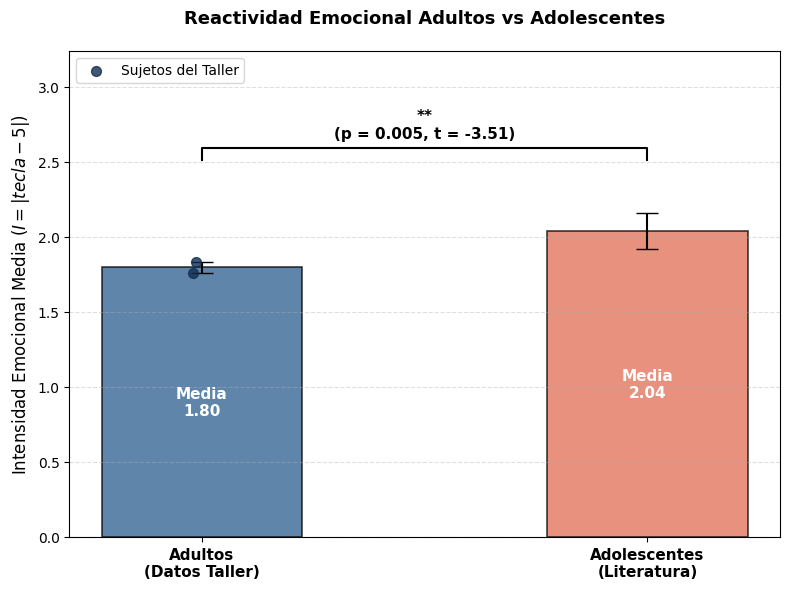

¡Gráfico guardado con éxito en: C:/Users/david/Downloads/results_\reactividad_emocional_adultos_vs_niños.png!


In [53]:
# ------------------------------------------------------------------------------
# Generación del Gráfico
# ------------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 6))

x = [0, 1]
means = [media_adultos, BENCHMARK_JONES_MEAN]
yerr = [
    [media_adultos - ci_low, BENCHMARK_JONES_MEAN - BENCHMARK_JONES_CI[0]],
    [ci_high - media_adultos, BENCHMARK_JONES_CI[1] - BENCHMARK_JONES_MEAN]
]

# Barras
bars = ax.bar(x, means, yerr=yerr, capsize=8, color=['#2b5c8f', '#e06d53'], alpha=0.75, width=0.45, edgecolor='black', linewidth=1.2)

# Etiquetas de valor en las barras
for bar, m in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, m/2, f"Media\n{m:.2f}", ha='center', va='center', color='white', fontweight='bold', fontsize=11)

# Puntos individuales de los adultos con jitter horizontal
if n_sujetos > 0:
    jitter = np.random.normal(0, 0.03, size=n_sujetos) if n_sujetos > 1 else [0]
    ax.scatter(jitter, scores, color='#112e51', s=50, alpha=0.8, zorder=3, label='Sujetos del Taller')


# ------------------------------------------------------------------------------
# Inserción de la barra de significación (Bracket & Estrellas + p-valor)
# ------------------------------------------------------------------------------
y_max = max(ci_high, BENCHMARK_JONES_CI[1]) + 0.35
h_bracket = 0.08

# Trazado del corchete
ax.plot([0, 0, 1, 1], [y_max, y_max + h_bracket, y_max + h_bracket, y_max], lw=1.5, c='black')

# Texto de significación estadística
p_texto = f"{estrellas}\n(p = {p_val:.3f}, t = {t_stat:.2f})" if p_val >= 0.001 else f"{estrellas}\n(p < 0.001, t = {t_stat:.2f})"
ax.text(0.5, y_max + h_bracket + 0.05, p_texto, ha='center', va='bottom', color='black', fontweight='bold', fontsize=11)

# Ajustes de formato visual
ax.set_xticks(x)
ax.set_xticklabels(['Adultos\n(Datos Taller)', 'Adolescentes\n(Literatura)'], fontsize=11, fontweight='bold')
ax.set_ylabel('Intensidad Emocional Media ($I = |tecla - 5|$)', fontsize=12)
ax.set_title('Reactividad Emocional Adultos vs Adolescentes', fontsize=13, fontweight='bold', pad=20)
ax.set_ylim(0, y_max + h_bracket + 0.65)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.legend(loc='upper left', frameon=True)

plt.tight_layout()

nombre_archivo = os.path.join(CARPETA_RESULTADOS, 'reactividad_emocional_adultos_vs_niños.png')

# Guardamos con fondo transparente y ajustando los bordes ajustados (transparent=True)
plt.savefig(nombre_archivo, dpi=300, transparent=True, bbox_inches='tight')
plt.show()

print(f"¡Gráfico guardado con éxito en: {nombre_archivo}!")

plt.show()